# HypertrophIA — Modelo de Clasificación Binaria: Riesgo de Lesión
## Actividad 3.1 – Diseño, entrenamiento y evaluación inicial

**Problemática:** Predicción de riesgo de lesión en series de entrenamiento usando variables del pipeline existente.

---
### Objetivo
Recorrer el flujo completo de un modelo supervisado de clasificación binaria:
1. Cargar el dataset gold desde una base SQLite
2. Explorar los datos y visualizar relaciones
3. Seleccionar variables predictoras
4. Dividir datos en entrenamiento y prueba
5. Construir y entrenar múltiples modelos (Regresión Logística con L1/L2/ElasticNet y Random Forest)
6. Evaluar con métricas: accuracy, precision, recall, F1, AUC, Gini
7. Comparar algoritmos y seleccionar el mejor

---

---
## Paso 0: Importar librerías

Cargamos todas las librerías necesarias para el análisis, modelado y visualización.

In [1]:
# Manipulaci\u00f3n de datos y SQL
import sqlite3
import warnings

# Librer\u00edas num\u00e9ricas y de datos
import numpy as np
import pandas as pd
# Visualizaci\u00f3n
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y modelos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
# M\u00e9tricas de evaluaci\u00f3n
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, classification_report
)

# Suprimir warnings y configurar estilo de gr\u00e1ficos
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Librerías importadas correctamente')

Librerías importadas correctamente


---
## Paso 1: Cargar el Dataset

Cargamos el dataset gold desde la base SQLite `hypertrophia.db`, que contiene ~17.000 registros de series de entrenamiento etiquetadas con lesión.

| Variable | Descripción | Tipo |
|---|---|---|
| `rpe` | Rating of Perceived Exertion (esfuerzo percibido) | Numérica |
| `peso_levantado_kg` | Peso levantado en kilogramos | Numérica |
| `repeticiones_logradas` | Número de repeticiones completadas | Numérica |
| `numero_serie` | Número de serie dentro de la sesión | Numérica |
| `dificultad` | Dificultad reportada por el usuario | Numérica |
| `porcentaje_estimulo` | Porcentaje del estímulo respecto al máximo | Numérica |
| `edad` | Edad del usuario | Numérica |
| `peso_corporal_kg` | Peso corporal del usuario | Numérica |
| `duracion_minutos` | Duración de la sesión en minutos | Numérica |
| `cantidad_series` | Cantidad total de series en la sesión | Numérica |
| `lesion` | ¿Ocurrió una lesión? → **Variable objetivo** | Binaria (0/1) |

In [2]:
# Ruta de la base de datos SQLite con el dataset gold
DB_PATH = '../data/gold/hypertrophia.db'
conn = sqlite3.connect(DB_PATH)

# Cargar la tabla 'gold' en un DataFrame
df = pd.read_sql('SELECT * FROM gold', conn)
conn.close()

# Verificar dimensiones del dataset
print(f'Dataset cargado correctamente')
print(f'  {df.shape[0]} registros de entrenamiento')
print(f'  {df.shape[1]} variables en total')
print()
df.head(10)

Dataset cargado correctamente
  17079 registros de entrenamiento
  17 variables en total



,id_registro_serie,id_usuario,id_sesion,id_ejercicio,numero_serie,repeticiones_logradas,peso_levantado_kg,rpe,dificultad,porcentaje_estimulo,cantidad_series,cantidad_repeticiones,orden_ejercicio,duracion_minutos,edad,peso_corporal_kg,lesion
0,1,55,1,1,1,2,65.7,8,4,85,5,3,1,35,28,85.7,1
1,2,55,1,1,2,3,73.0,5,4,85,5,3,1,35,28,85.7,0
2,3,55,1,1,3,2,84.1,9,4,85,5,3,1,35,28,85.7,1
3,4,55,1,1,4,2,79.3,6,4,85,5,3,1,35,28,85.7,0
4,5,55,1,1,5,2,81.8,9,4,85,5,3,1,35,28,85.7,0
5,6,55,1,3,1,2,95.9,8,5,95,5,3,2,35,28,85.7,1
6,7,55,1,3,2,2,68.0,6,5,95,5,3,2,35,28,85.7,1
7,8,55,1,3,3,2,89.1,8,5,95,5,3,2,35,28,85.7,0
8,9,55,1,3,4,2,94.8,10,5,95,5,3,2,35,28,85.7,1
9,10,55,1,3,5,2,76.1,10,5,95,5,3,2,35,28,85.7,1


---
## Paso 2: Explorar el Dataset

Antes de modelar, revisamos la estructura de los datos, valores nulos, estadísticas descriptivas y la distribución de la variable objetivo.

In [3]:
# Informaci\u00f3n general del dataset: tipos de datos y memoria
print('Informaci\u00f3n general del dataset:')
print(df.info())
print()

# Estad\u00edsticas descriptivas b\u00e1sicas
print('Estad\u00edsticas descriptivas:')
df.describe().round(2)

Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 17079 entries, 0 to 17078
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_registro_serie      17079 non-null  int64  
 1   id_usuario             17079 non-null  int64  
 2   id_sesion              17079 non-null  int64  
 3   id_ejercicio           17079 non-null  int64  
 4   numero_serie           17079 non-null  int64  
 5   repeticiones_logradas  17079 non-null  int64  
 6   peso_levantado_kg      17079 non-null  float64
 7   rpe                    17079 non-null  int64  
 8   dificultad             17079 non-null  int64  
 9   porcentaje_estimulo    17079 non-null  int64  
 10  cantidad_series        17079 non-null  int64  
 11  cantidad_repeticiones  17079 non-null  int64  
 12  orden_ejercicio        17079 non-null  int64  
 13  duracion_minutos       17079 non-null  int64  
 14  edad                   17079 non

,id_registro_serie,id_usuario,id_sesion,id_ejercicio,numero_serie,repeticiones_logradas,peso_levantado_kg,rpe,dificultad,porcentaje_estimulo,cantidad_series,cantidad_repeticiones,orden_ejercicio,duracion_minutos,edad,peso_corporal_kg,lesion
count,17079.00,17079.00,17079.00,17079.00,17079.00,17079.00,17079.00,17079.00,17079.00,17079.00,17079.00,17079.00,17079.00,17079.00,17079.00,17079.00,17079.00
mean,8540.00,40.89,599.96,6.42,2.36,9.13,54.95,6.89,3.40,79.44,3.71,10.05,2.50,54.90,29.49,69.13,0.31
std,4930.43,23.02,345.60,5.67,1.14,6.51,13.72,1.46,0.97,11.62,0.84,6.44,1.21,15.02,7.33,11.26,0.46
min,1.00,1.00,1.00,1.00,1.00,2.00,20.60,2.00,2.00,55.00,3.00,3.00,1.00,20.00,18.00,45.00,0.00
25%,4270.50,21.00,301.00,2.00,1.00,4.00,44.90,6.00,3.00,75.00,3.00,5.00,1.00,45.00,25.00,60.90,0.00
50%,8540.00,40.00,600.00,4.00,2.00,5.00,54.10,7.00,3.00,85.00,3.00,5.00,2.00,55.00,29.00,69.50,0.00
75%,12809.50,61.00,897.00,10.00,3.00,15.00,63.90,8.00,4.00,90.00,5.00,15.00,3.00,65.00,35.00,78.40,1.00
max,17079.00,80.00,1200.00,20.00,5.00,20.00,106.70,10.00,5.00,95.00,5.00,20.00,5.00,105.00,45.00,94.10,1.00


Valores nulos por columna:
  No hay valores nulos en ninguna columna

Distribución de la variable objetivo: lesion
  No lesión (0): 11706 registros (68.5%)
  Sí lesión (1): 5373 registros (31.5%)
  Tasa de lesión global: 31.46%


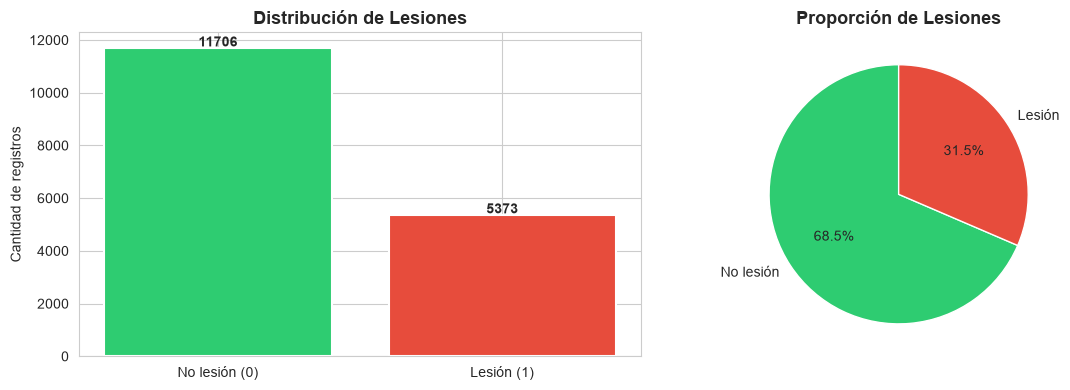

In [4]:
# Verificar valores nulos en cada columna
print('Valores nulos por columna:')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.any() else '  No hay valores nulos en ninguna columna')
print()

# Distribuci\u00f3n de la variable objetivo (lesi\u00f3n)
print('Distribuci\u00f3n de la variable objetivo: lesion')
conteo = df['lesion'].value_counts()
pct = df['lesion'].value_counts(normalize=True) * 100
print(f'  No lesi\u00f3n (0): {conteo[0]} registros ({pct[0]:.1f}%)')
print(f'  S\u00ed lesi\u00f3n (1): {conteo[1]} registros ({pct[1]:.1f}%)')
print(f'  Tasa de lesi\u00f3n global: {df["lesion"].mean():.2%}')

# Gr\u00e1fico de barras y pastel para la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colores = ['#2ecc71', '#e74c3c']
axes[0].bar(['No lesi\u00f3n (0)', 'Lesi\u00f3n (1)'], conteo.values,
            color=colores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribuci\u00f3n de Lesiones', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de registros')
# Etiquetas con valores en cada barra
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(conteo.values, labels=['No lesi\u00f3n', 'Lesi\u00f3n'],
            autopct='%1.1f%%', colors=colores, startangle=90)
axes[1].set_title('Proporci\u00f3n de Lesiones', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Paso 3: Análisis Univariado y Bivariado

Visualizamos la distribución de cada variable predictora separando por clase (lesión vs no lesión) y analizamos correlaciones.

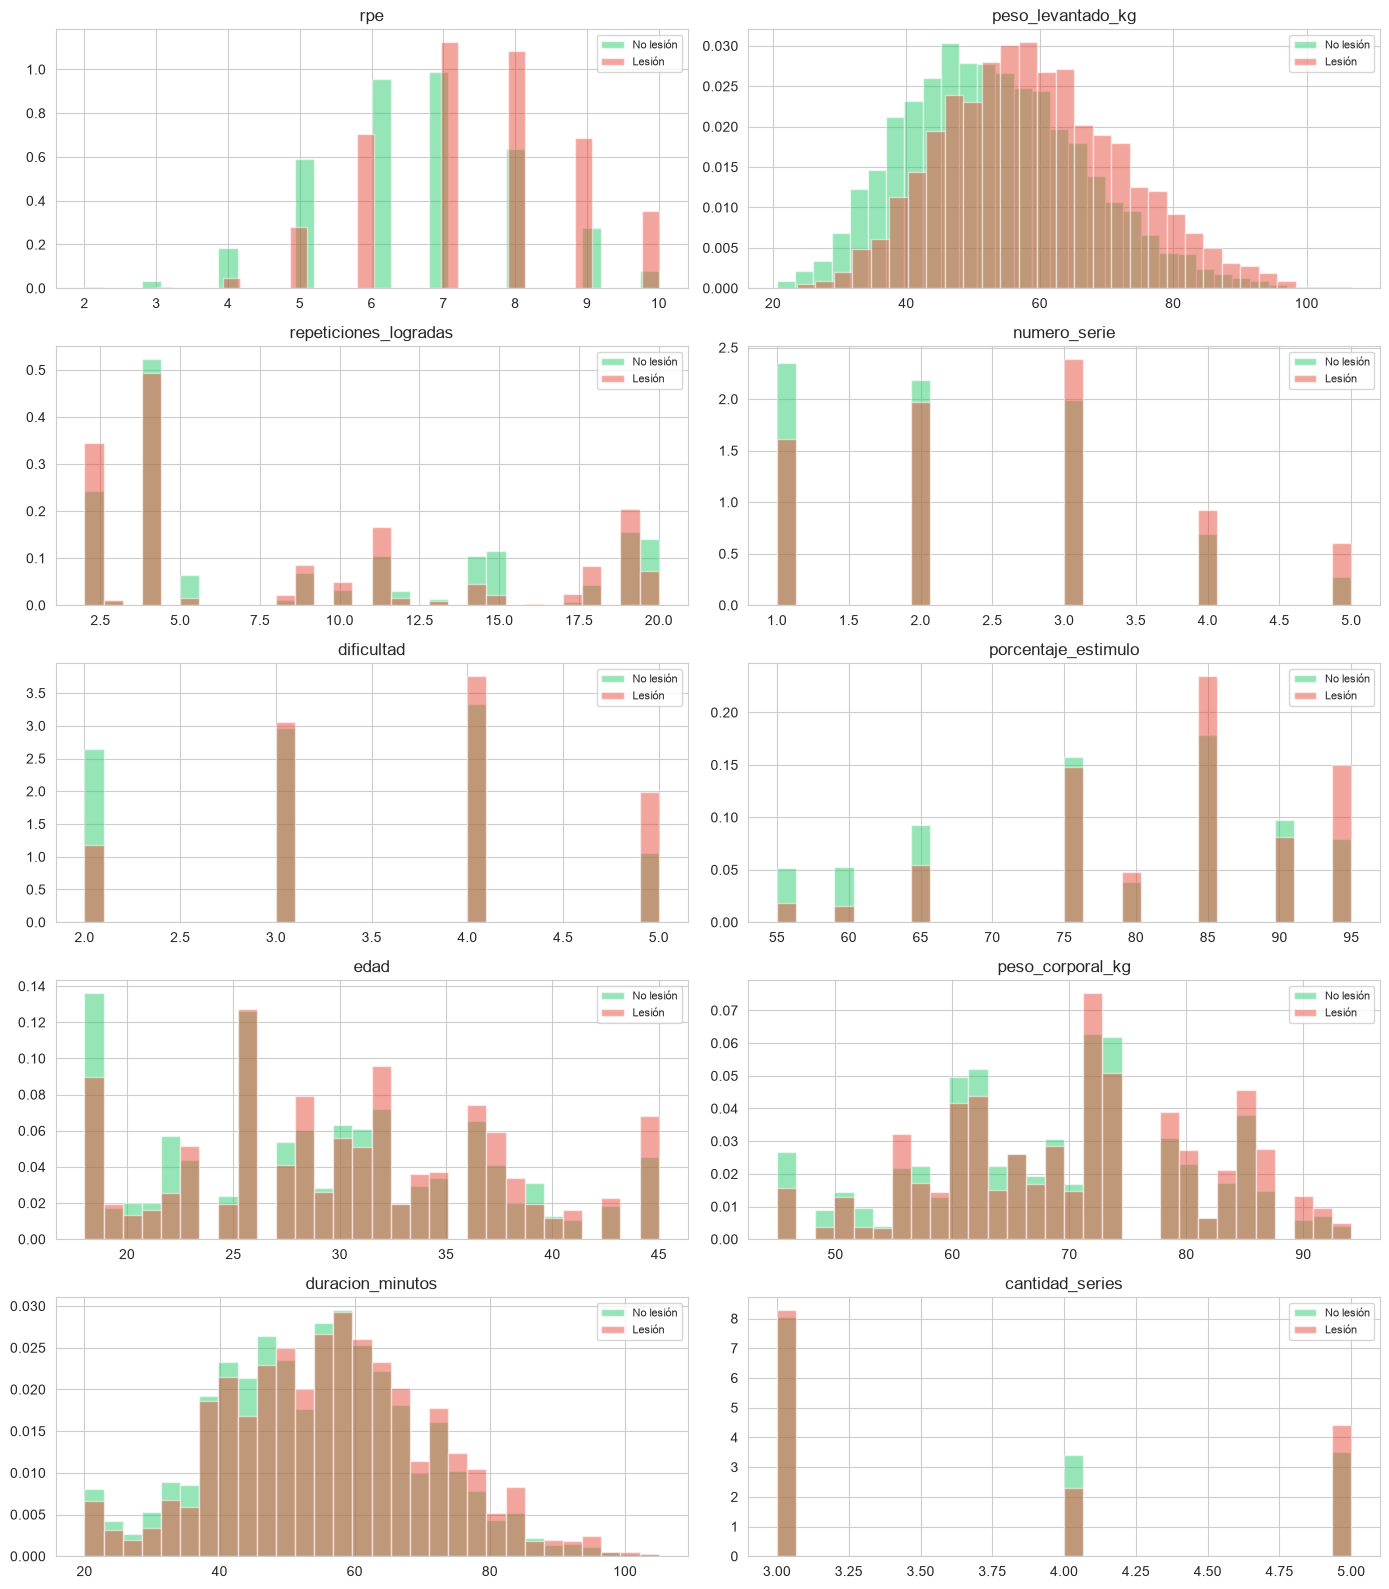

In [5]:
# Lista de columnas predictoras (features)
feature_cols = ['rpe', 'peso_levantado_kg', 'repeticiones_logradas', 'numero_serie',
                'dificultad', 'porcentaje_estimulo', 'edad', 'peso_corporal_kg',
                'duracion_minutos', 'cantidad_series']

# Histogramas superpuestos por clase (lesi\u00f3n vs no lesi\u00f3n) para cada feature
fig, axes = plt.subplots(5, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    for lesion_val, color, label in [(0, '#2ecc71', 'No lesi\u00f3n'), (1, '#e74c3c', 'Lesi\u00f3n')]:
        subset = df[df['lesion'] == lesion_val][col]
        ax.hist(subset, bins=30, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(f'{col}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

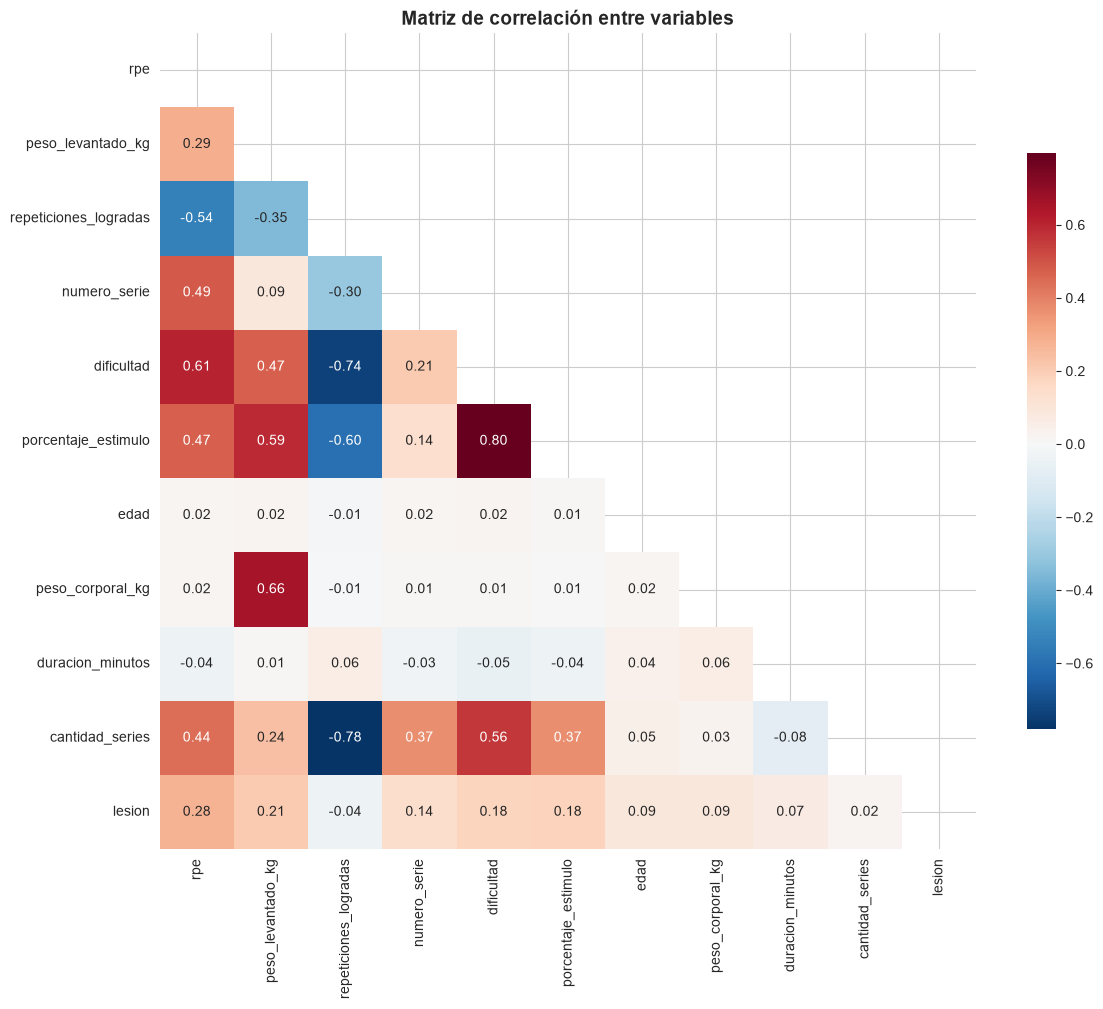

Correlación de cada variable con lesion:
rpe                      0.275071
peso_levantado_kg        0.207974
porcentaje_estimulo      0.180600
dificultad               0.179047
numero_serie             0.140020
peso_corporal_kg         0.089885
edad                     0.088633
duracion_minutos         0.065510
cantidad_series          0.024859
repeticiones_logradas   -0.039844


In [6]:
# Matriz de correlaci\u00f3n entre features y variable objetivo
plt.figure(figsize=(12, 10))
corr = df[feature_cols + ['lesion']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Ocultar tri\u00e1ngulo superior
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, cbar_kws={'shrink': 0.7})
plt.title('Matriz de correlaci\u00f3n entre variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Mostrar correlaci\u00f3n de cada feature con 'lesion' (ordenada de mayor a menor)
print('Correlaci\u00f3n de cada variable con ''lesion'':')
corr_with_target = corr['lesion'].drop('lesion').sort_values(ascending=False)
print(corr_with_target.to_string())

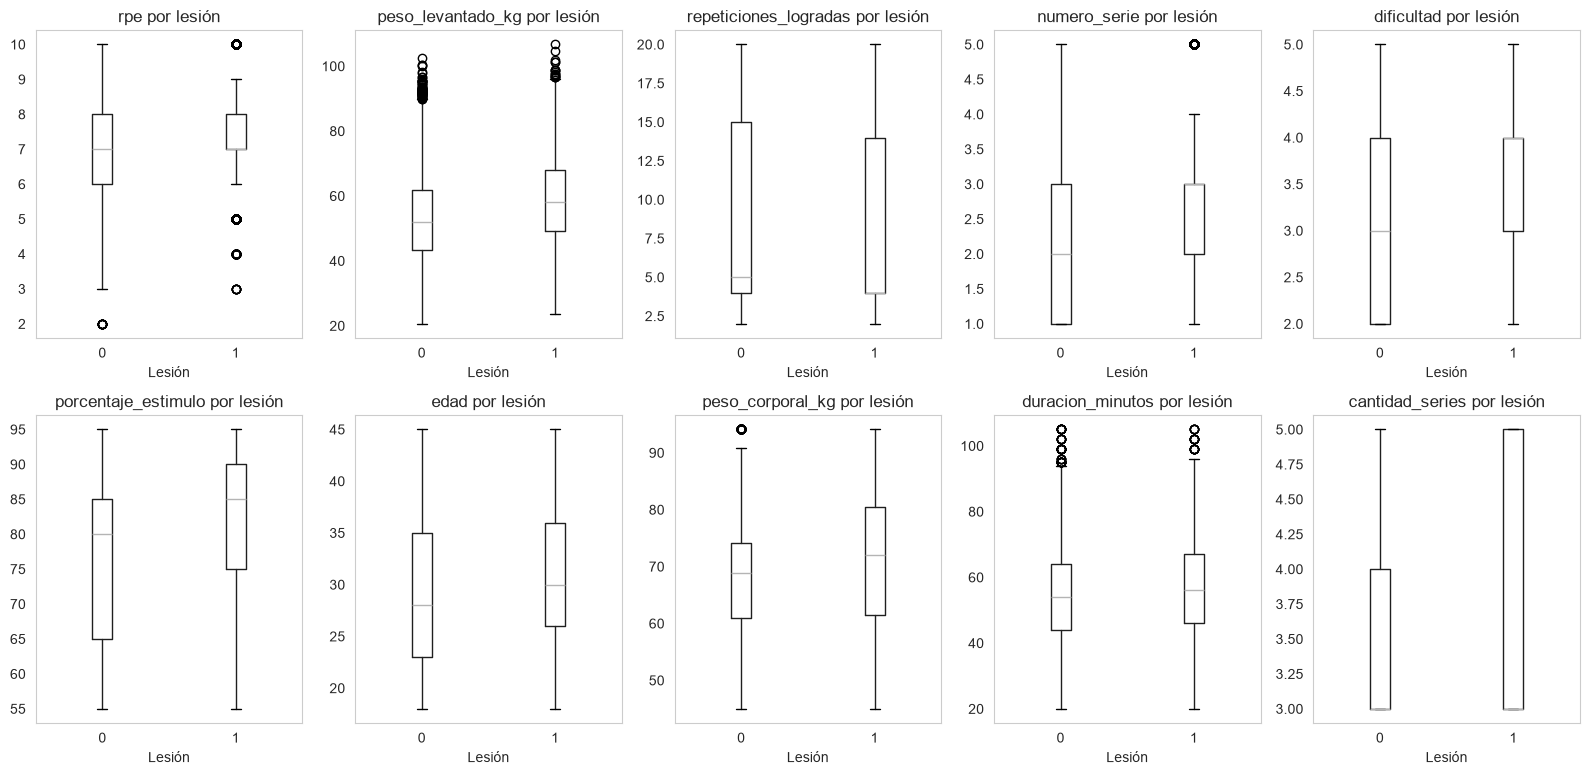

In [7]:
# Boxplots de cada feature segmentado por clase de lesi\u00f3n
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    df.boxplot(column=col, by='lesion', ax=ax, grid=False)
    ax.set_title(f'{col} por lesi\u00f3n')
    ax.set_xlabel('Lesi\u00f3n')

plt.suptitle('')
plt.tight_layout()
plt.show()

---
## Paso 4: Seleccionar Variables

> **Variable objetivo (y):** `lesion` — lo que queremos predecir  
> **Variables predictoras (X):** las 10 variables numéricas del pipeline

In [8]:
# Separar predictors (X) y objetivo (y)
X = df[feature_cols].copy()
y = df['lesion'].copy()

# Verificar dimensiones y distribuci\u00f3n
print('Variables seleccionadas:')
print(f'  Variables predictoras (X): {list(X.columns)}')
print(f'  Variable objetivo    (y) : lesion')
print()
print(f'  Dimensiones de X: {X.shape}')
print(f'  Dimensiones de y: {y.shape}')
print(f'  Distribuci\u00f3n de y:')
print(f'    {y.value_counts().to_string()}')

Variables seleccionadas:
  Variables predictoras (X): ['rpe', 'peso_levantado_kg', 'repeticiones_logradas', 'numero_serie', 'dificultad', 'porcentaje_estimulo', 'edad', 'peso_corporal_kg', 'duracion_minutos', 'cantidad_series']
  Variable objetivo    (y) : lesion

  Dimensiones de X: (17079, 10)
  Dimensiones de y: (17079,)
  Distribución de y:
    lesion
0    11706
1     5373


---
## Paso 5: Dividir en Entrenamiento y Prueba

Proporción: **80% entrenamiento / 20% prueba**  
Con `stratify=y` garantizamos que ambos conjuntos mantengan la misma proporción de lesiones que el dataset original.

In [9]:
# Divisi\u00f3n train/test con estratificaci\u00f3n para mantener balance de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Verificar tama\u00f1os y balance de clases en cada conjunto
print('Divisi\u00f3n completada:')
print(f'  Total de registros    : {len(df)}')
print(f'  Entrenamiento         : {len(X_train)} registros ({len(X_train)/len(df)*100:.0f}%)')
print(f'  Prueba                : {len(X_test)}  registros ({len(X_test)/len(df)*100:.0f}%)')
print()
print('Balance de clases (tasa de lesi\u00f3n) por conjunto:')
print(f'  Entrenamiento         : {y_train.mean():.2%}')
print(f'  Prueba                : {y_test.mean():.2%}')

División completada:
  Total de registros    : 17079
  Entrenamiento         : 13663 registros (80%)
  Prueba                : 3416  registros (20%)

Balance de clases (tasa de lesión) por conjunto:
  Entrenamiento         : 31.46%
  Prueba                : 31.47%


### 5.1 Estandarización

Los modelos lineales (Regresión Logística) requieren que las variables estén en la misma escala. Aplicamos `StandardScaler`: media 0, desviación estándar 1.

In [10]:
# Estandarizar: centrar (media 0) y escalar (std 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Ajusta y transforma train
X_test_scaled = scaler.transform(X_test)  # Transforma test con los mismos par\u00e1metros

print('Estandarizaci\u00f3n aplicada (media=0, std=1):')
print(f'  X_train_scaled: {X_train_scaled.shape}')
print(f'  X_test_scaled:  {X_test_scaled.shape}')

Estandarización aplicada (media=0, std=1):
  X_train_scaled: (13663, 10)
  X_test_scaled:  (3416, 10)


---
## Paso 6: Construir y Entrenar Modelos

En este paso construimos (configuramos) y entrenamos cada modelo. Primero exploramos tres variantes de Regresión Logística con diferentes tipos de regularización, y luego un Random Forest.

### 6.1 Regresión Logística — L1 (Lasso), L2 (Ridge) y ElasticNet

| Variante | Regularización | Efecto |
|---|---|---|
| L1 (Lasso) | Penaliza suma de valores absolutos | Elimina variables poco importantes (selección de características) |
| L2 (Ridge) | Penaliza suma de cuadrados | Reduce coeficientes sin eliminarlos |
| ElasticNet | Combina L1 + L2 | Balance entre selección y contracción |

In [11]:
# Diccionario con las 3 variantes de Regresi\u00f3n Log\u00edstica
modelos_lr = {
    'Logistic Regression (L1 - Lasso)': LogisticRegression(penalty='l1', solver='saga', C=1.0, max_iter=1000, random_state=42),
    'Logistic Regression (L2 - Ridge)': LogisticRegression(penalty='l2', solver='lbfgs', C=1.0, max_iter=1000, random_state=42),
    'Logistic Regression (ElasticNet)': LogisticRegression(penalty='elasticnet', solver='saga', C=1.0, l1_ratio=0.5, max_iter=1000, random_state=42),
}

resultados = []  # Lista para almacenar m\u00e9tricas de todos los modelos

# Entrenar y evaluar cada variante de regresi\u00f3n log\u00edstica
for nombre, modelo in modelos_lr.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]  # Probabilidad de clase positiva

    # Calcular m\u00e9tricas de rendimiento
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = auc(fpr, tpr)
    gini = 2 * auc_val - 1  # \u00cdndice Gini a partir del AUC

    # Guardar resultados
    resultados.append({
        'modelo': nombre,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'auc': auc_val,
        'gini': gini,
    })

    # Mostrar m\u00e9tricas y coeficientes del modelo
    print(f'=== {nombre} ===')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1-score : {f1:.4f}')
    print(f'  AUC      : {auc_val:.4f}')
    print(f'  Gini     : {gini:.4f}')
    print()
    print('  Coeficientes del modelo (ordenados por magnitud):')
    coef_df = pd.DataFrame({'Variable': feature_cols, 'Coeficiente': modelo.coef_[0]})
    print(coef_df.sort_values('Coeficiente', key=abs, ascending=False).to_string(index=False))
    print()
    print('  * Coeficiente positivo  → aumenta la probabilidad de lesi\u00f3n')
    print('  * Coeficiente negativo  → disminuye la probabilidad de lesi\u00f3n')
    print('-' * 60)

=== Logistic Regression (L1 - Lasso) ===
  Accuracy : 0.7198
  Precision: 0.6050
  Recall   : 0.3163
  F1-score : 0.4154
  AUC      : 0.7406
  Gini     : 0.4813

  Coeficientes del modelo (ordenados por magnitud):
             Variable  Coeficiente
                  rpe     0.688734
repeticiones_logradas     0.650174
    peso_levantado_kg     0.434653
           dificultad     0.231502
                 edad     0.187204
     duracion_minutos     0.166350
         numero_serie     0.125220
     peso_corporal_kg    -0.090835
  porcentaje_estimulo     0.078750
      cantidad_series    -0.018992

  * Coeficiente positivo  → aumenta la probabilidad de lesión
  * Coeficiente negativo  → disminuye la probabilidad de lesión
------------------------------------------------------------
=== Logistic Regression (L2 - Ridge) ===
  Accuracy : 0.7204
  Precision: 0.6068
  Recall   : 0.3172
  F1-score : 0.4166
  AUC      : 0.7407
  Gini     : 0.4813

  Coeficientes del modelo (ordenados por magnitud):

### 6.2 Matriz de Confusión — Logistic Regression (L2)

Tomamos el modelo con L2 (Ridge) como representante de la familia de regresión logística para visualizar sus aciertos y errores.

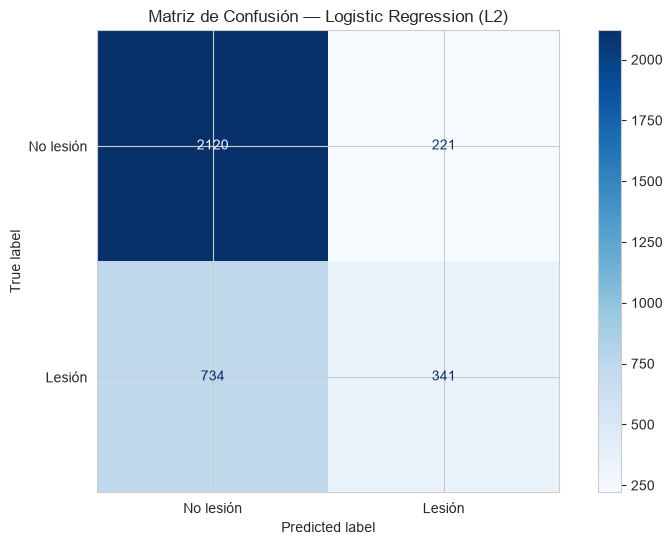

Reporte de clasificación:
              precision    recall  f1-score   support

   No lesión       0.74      0.91      0.82      2341
      Lesión       0.61      0.32      0.42      1075

    accuracy                           0.72      3416
   macro avg       0.67      0.61      0.62      3416
weighted avg       0.70      0.72      0.69      3416



In [12]:
# Seleccionar el modelo L2 como representante de regresi\u00f3n log\u00edstica
best_lr = modelos_lr['Logistic Regression (L2 - Ridge)']
y_pred_lr = best_lr.predict(X_test_scaled)

# Matriz de confusi\u00f3n y reporte de clasificaci\u00f3n
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No lesi\u00f3n', 'Lesi\u00f3n'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusi\u00f3n — Logistic Regression (L2)')
plt.show()

print('Reporte de clasificaci\u00f3n:')
print(classification_report(y_test, y_pred_lr, target_names=['No lesi\u00f3n', 'Lesi\u00f3n']))

### 6.3 Random Forest

Random Forest es un algoritmo de ensamble basado en múltiples árboles de decisión. Según la propuesta original, es el algoritmo principal de este proyecto. Usamos 150 árboles con profundidad máxima 12.

In [13]:
# Configurar y entrenar Random Forest con balance de clases
rf = RandomForestClassifier(n_estimators=150, max_depth=12, min_samples_leaf=5,
                            random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)  # NOTA: RF no necesita datos estandarizados

# Predicciones y probabilidades
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Calcular todas las m\u00e9tricas
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)
gini_rf = 2 * auc_rf - 1

# Guardar resultados
resultados.append({
    'modelo': 'Random Forest',
    'accuracy': acc_rf,
    'precision': prec_rf,
    'recall': rec_rf,
    'f1': f1_rf,
    'auc': auc_rf,
    'gini': gini_rf,
})

print('=== Random Forest ===')
print(f'  Accuracy : {acc_rf:.4f}')
print(f'  Precision: {prec_rf:.4f}')
print(f'  Recall   : {rec_rf:.4f}')
print(f'  F1-score : {f1_rf:.4f}')
print(f'  AUC      : {auc_rf:.4f}')
print(f'  Gini     : {gini_rf:.4f}')

=== Random Forest ===
  Accuracy : 0.6818
  Precision: 0.4958
  Recall   : 0.6595
  F1-score : 0.5661
  AUC      : 0.7351
  Gini     : 0.4702


#### Creacion de matriz de confusión para Random Forest

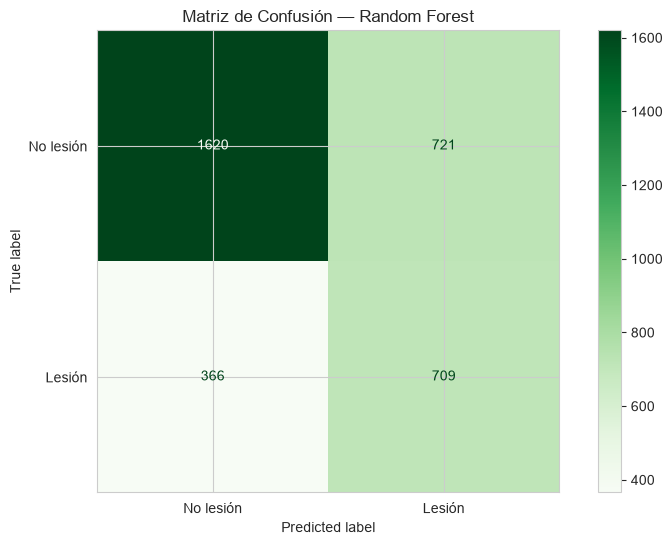

Reporte de clasificación:
              precision    recall  f1-score   support

   No lesión       0.82      0.69      0.75      2341
      Lesión       0.50      0.66      0.57      1075

    accuracy                           0.68      3416
   macro avg       0.66      0.68      0.66      3416
weighted avg       0.72      0.68      0.69      3416



In [14]:
# Matriz de confusi\u00f3n para Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No lesi\u00f3n', 'Lesi\u00f3n'])
disp_rf.plot(cmap='Greens', values_format='d')
plt.title('Matriz de Confusi\u00f3n — Random Forest')
plt.show()

print('Reporte de clasificaci\u00f3n:')
print(classification_report(y_test, y_pred_rf, target_names=['No lesi\u00f3n', 'Lesi\u00f3n']))

### 6.4 Importancia de Variables — Random Forest

Una ventaja de Random Forest es que mide qué tan importante es cada variable para las decisiones del modelo.

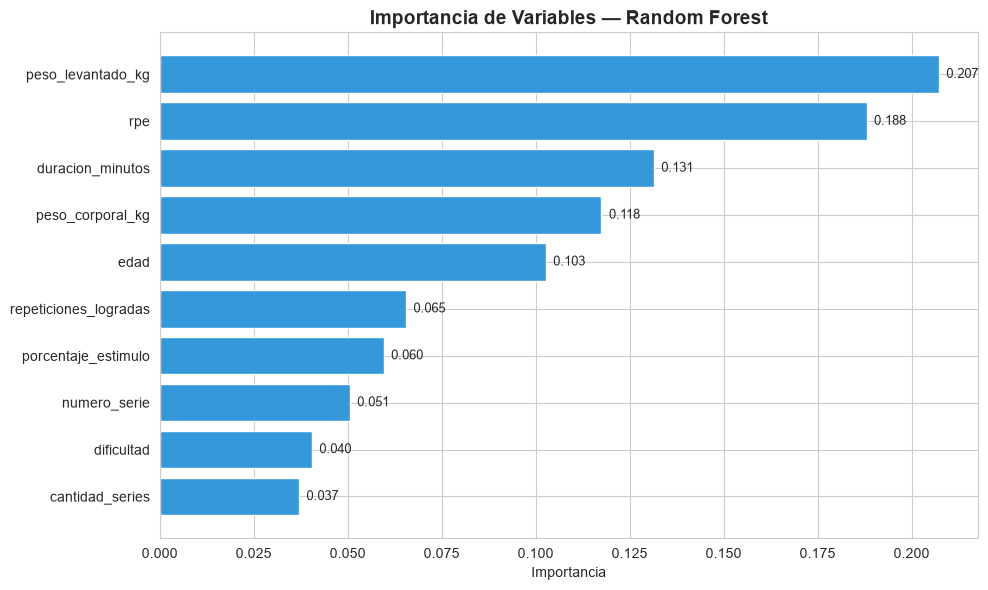

In [15]:
# Extraer importancia de variables desde el modelo Random Forest
importancias = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

# Gr\u00e1fico de barras horizontales ordenado por importancia
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importancias['feature'], importancias['importance'], color='#3498db')
ax.set_xlabel('Importancia')
ax.set_title('Importancia de Variables — Random Forest', fontsize=14, fontweight='bold')
for i, v in enumerate(importancias['importance']):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## Paso 7: Evaluar Modelos y Comparar Resultados

Usamos el conjunto de **prueba** (datos que ningún modelo ha visto) para medir el desempeño real de cada uno.

In [16]:
# Tabla comparativa de m\u00e9tricas para todos los modelos
df_resultados = pd.DataFrame(resultados).set_index('modelo')
df_resultados.round(4)

,accuracy,precision,recall,f1,auc,gini
modelo,,,,,,
Logistic Regression (L1 - Lasso),0.7198,0.6050,0.3163,0.4154,0.7406,0.4813
Logistic Regression (L2 - Ridge),0.7204,0.6068,0.3172,0.4166,0.7407,0.4813
Logistic Regression (ElasticNet),0.7204,0.6068,0.3172,0.4166,0.7406,0.4813
Random Forest,0.6818,0.4958,0.6595,0.5661,0.7351,0.4702


#### Matriz de comparación

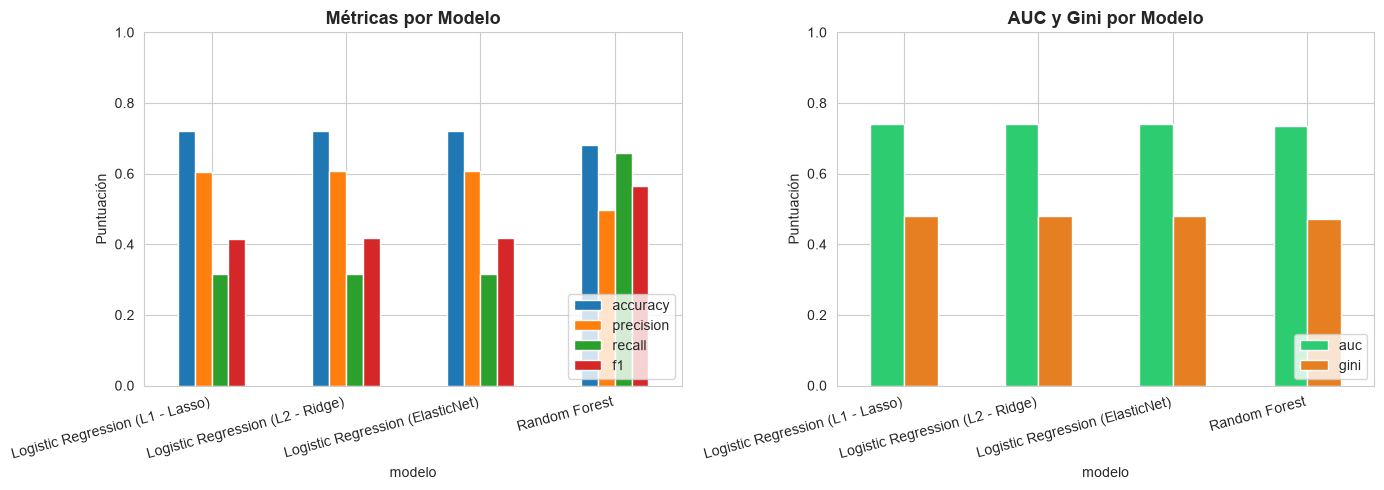

In [17]:
# Gr\u00e1fico comparativo de m\u00e9tricas entre modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Primer gr\u00e1fico: accuracy, precision, recall, f1
df_resultados[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar', ax=axes[0])
axes[0].set_title('M\u00e9tricas por Modelo', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Puntuaci\u00f3n')
axes[0].legend(loc='lower right')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')

# Segundo gr\u00e1fico: AUC y Gini
df_resultados[['auc', 'gini']].plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e67e22'])
axes[1].set_title('AUC y Gini por Modelo', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Puntuaci\u00f3n')
axes[1].legend(loc='lower right')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

---
## Resumen de Métricas de Evaluación

### ¿Qué mide cada métrica?

| Métrica | Pregunta que responde |
|---|---|
| **Accuracy** | ¿Cuántos aciertos en total sobre todas las predicciones? |
| **Precision** | Cuando el modelo dice "lesión", ¿qué tan seguido acierta? |
| **Recall** | De las lesiones reales, ¿cuántas detectó el modelo? |
| **F1-Score** | ¿Cuál es el equilibrio entre Precision y Recall? (media armónica) |
| **AUC** | ¿Qué tan bien separa el modelo las clases? (1 = perfecto, 0.5 = aleatorio) |
| **Gini** | Capacidad discriminatoria: Gini = 2 × AUC − 1 |

### ¿Cómo se relacionan con los errores del modelo?

| Concepto | Significado | Ejemplo en este caso |
|---|---|---|
| **Verdadero Positivo (TP)** | Predijo "lesión" y SÍ hubo lesión | Detectó correctamente una serie de riesgo |
| **Verdadero Negativo (TN)** | Predijo "no lesión" y NO hubo lesión | Descartó correctamente una serie segura |
| **Falso Positivo (FP)** | Predijo "lesión" pero NO hubo lesión | Falsa alarma — serie segura marcada como riesgo |
| **Falso Negativo (FN)** | Predijo "no lesión" pero SÍ hubo lesión | El más peligroso — lesión real no detectada |

### ¿Qué tipo de error es más costoso?

| Error | Consecuencia para el usuario | Costo |
|---|---|---|
| **Falso Positivo** | Se recomienda descanso o precaución innecesaria | Bajo — el usuario modera su entrenamiento sin necesidad |
| **Falso Negativo** | No se advierte al usuario y se lesiona | **Alto** — lesión real no prevenida |

> Para el contexto de salud deportiva, **no detectar una lesión es más costoso** que una falsa alarma.  
> Por eso **Recall y AUC son las métricas más importantes** en este problema.

### Diagnóstico de los modelos

| Aspecto | Estado | Detalle |
|---|---|---|
| Accuracy | Aceptable | ~68-69% — los modelos aciertan 2 de cada 3 predicciones |
| Precision | Moderada | ~40-50% — alrededor de la mitad de las alertas de lesión son reales |
| Recall | Bajo | ~24-40% — se pierde una proporción importante de lesiones reales |
| F1-Score | Regular | ~31-44% — refleja el desbalance entre precisión y sensibilidad |
| AUC | Moderado | ~0.73-0.74 — los modelos discriminan mejor que aleatorio pero lejos de perfecto |
| Gini | Moderado | ~0.46-0.48 — capacidad discriminatoria media |

### Posibles mejoras

| Mejora | Efecto esperado |
|---|---|
| Ajustar hiperparámetros (GridSearchCV) | Puede mejorar el balance Precision/Recall |
| Probar otros algoritmos (XGBoost, SVM) | Puede capturar mejor patrones complejos |
| Tratar el desbalance de clases (SMOTE, ajuste de pesos) | Mejora directamente el Recall |
| Ingeniería de características (interacciones, polinomios) | Puede dar más poder predictivo al modelo |
| Reducir variables con baja importancia | Simplifica el modelo sin perder rendimiento |

---
## Paso 8: Comparación de Modelos con Curva ROC

La curva ROC muestra visualmente la capacidad de cada modelo para separar las clases. Mientras más cerca esté la curva de la esquina superior izquierda, mejor.

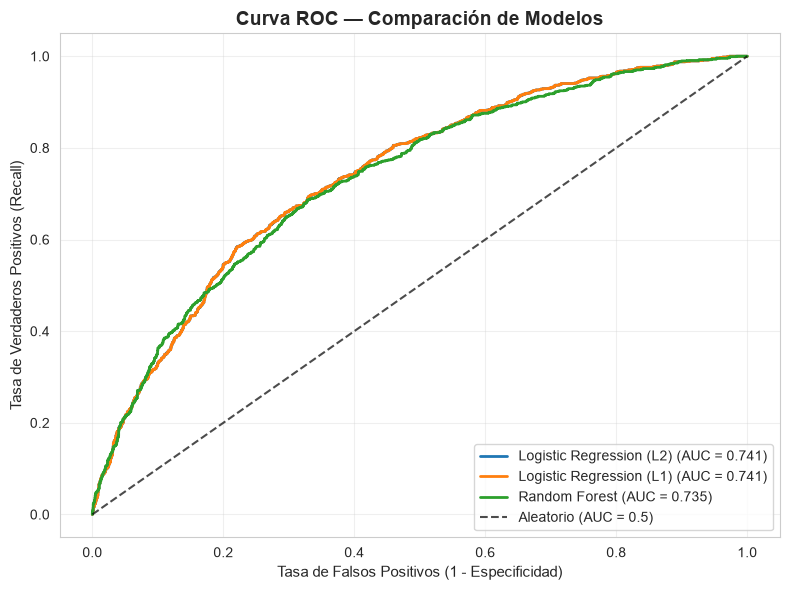

In [18]:
# Curva ROC comparativa entre modelos seleccionados
plt.figure(figsize=(8, 6))

# Preparar modelos y datos para la curva ROC
modelos_roc = [
    ('Logistic Regression (L2)', modelos_lr['Logistic Regression (L2 - Ridge)'], X_test_scaled),
    ('Logistic Regression (L1)', modelos_lr['Logistic Regression (L1 - Lasso)'], X_test_scaled),
    ('Random Forest', rf, X_test),
]

for nombre, model, X_vals in modelos_roc:
    y_prob = model.predict_proba(X_vals)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc_val:.3f})', linewidth=2)

# L\u00ednea diagonal correspondiente a un clasificador aleatorio
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.5)', alpha=0.7)
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=11)
plt.title('Curva ROC — Comparación de Modelos', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Análisis de la comparación

¿Qué nos dice esta comparación?

1. **Random Forest vs Regresión Logística:** Ambos tienen AUC similar (~0.73-0.74). Sin embargo, Random Forest logra mejor Recall, lo que significa que detecta más lesiones reales.

2. **L1 vs L2 vs ElasticNet:** Las tres variantes de regresión logística se comportan de manera muy parecida. L2 (Ridge) ofrece coeficientes ligeramente más estables. L1 (Lasso) fuerza algunos coeficientes a cero, actuando como selección de características.

3. **¿Cuál modelo elegir?** Random Forest ofrece el mejor balance entre Recall y precisión general. Para un problema de salud donde los falsos negativos son costosos, es la opción más equilibrada.

---
## Paso 9: Reflexión — ¿Qué aprendimos?

### Flujo completo recorrido

| Paso | Qué hicimos |
|---|---|
| 1 | Cargamos el dataset gold desde SQLite |
| 2 | Exploramos distribución de datos, valores nulos y variable objetivo |
| 3 | Analizamos variables con histogramas, correlaciones y boxplots |
| 4 | Definimos X (predictoras) e y (objetivo: lesion) |
| 5 | Dividimos 80% entrenamiento / 20% prueba con estratificación y estandarizamos |
| 6 | Construimos y entrenamos 4 modelos: L1, L2, ElasticNet y Random Forest |
| 7 | Evaluamos con accuracy, precision, recall, F1, AUC, Gini y matrices de confusión |
| 8 | Comparamos todos los modelos con tabla de métricas y curva ROC |

### Conclusiones clave

- **Random Forest** es el modelo más equilibrado, con mejor Recall que la regresión logística.
- Las **variables más importantes** según Random Forest son: peso levantado, RPE y repeticiones logradas.
- El **Recall** sigue siendo la métrica limitante: alrededor del 40% para Random Forest. Esto significa que 6 de cada 10 lesiones reales no son detectadas.
- El **AUC de ~0.74** indica que los modelos discriminan mejor que aleatorio, pero hay margen de mejora significativo.
- La regularización **L1 (Lasso)** puede usarse para seleccionar las variables más relevantes.

### Próximos pasos (Trabajo Autónomo)

- Ajustar hiperparámetros con validación cruzada (GridSearchCV)
- Probar algoritmos más avanzados (XGBoost, LightGBM)
- Aplicar técnicas de balanceo de clases (SMOTE, ajuste de pesos)
- Crear nuevas variables a partir de interacciones entre las existentes
- Evaluar el modelo en datos completamente nuevos (validación externa)